In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

dataset_url = 'https://raw.githubusercontent.com/lybrac/Achmad-Abidy_2411532017_ML2526/refs/heads/master/praktium%203/diabetes.csv'
df = pd.read_csv(dataset_url)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
from itertools import count
from seaborn._core.typing import ColumnName
import math

#distribution
def plotPerColumnDistribution(df, nGraphShown, nGraphPerRow):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col]>1 and nunique[col] < 50]]
    nRow, nCol = df.shape
    ColumnNames = list(df)
    nGraphRow = math.ceil(nCol/nGraphPerRow)
    plt.figure(num=None, figsize=(6*nGraphPerRow, 4*nGraphRow), dpi= 80, facecolor='w', edgecolor='k')
    for i in range(min(nCol, nGraphShown)):
      plt.subplot(nGraphRow, nGraphPerRow, i+1)
      columnDf = df.iloc[:, i]
      if(not np.issubdtype(type(columnDf.iloc[0]), np.number)):
        valueCounts= columnDf.value_counts()
        valueCounts.plot.bar()
      else:
        columnDf.hist()
      plt.ylabel('counts')
      plt.xticks(rotation=90)
      plt.title(f'{ColumnNames[i]} (column {i})')
    plt.tight_layout(pad=1.0, w_pad=1.0, h_pad=1.0)
    plt.show

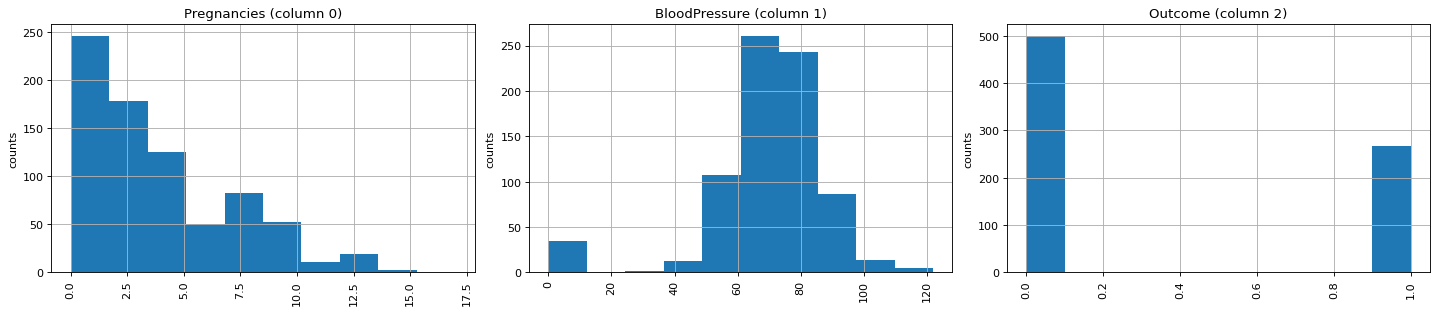

In [10]:
plotPerColumnDistribution(df, 10, 5)

In [16]:
from matplotlib import axis
#corelation
def plotCorrelationMatrix(df, graphWidth, title_name):
    filename = title_name
    df= df.dropna(axis='columns')
    # Filtering columns that have more than one unique value (i.e., not constant)
    df_filtered = df.loc[:, df.nunique() > 1]

    if df_filtered.shape[1]<2:
      print(f'No correlation plots shown: The number of non-NaN or constant columns ({df_filtered.shape[1]}) is less than 2')
      return
    corr = df_filtered.corr()
    fig, ax = plt.subplots(figsize=(graphWidth, graphWidth), dpi=80, facecolor='w', edgecolor='k')
    corrMat = ax.matshow(corr)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.gca().xaxis.tick_bottom()
    plt.colorbar(corrMat)
    plt.title(f'Correlation Matrix for {filename}', fontsize=15)
    plt.show()

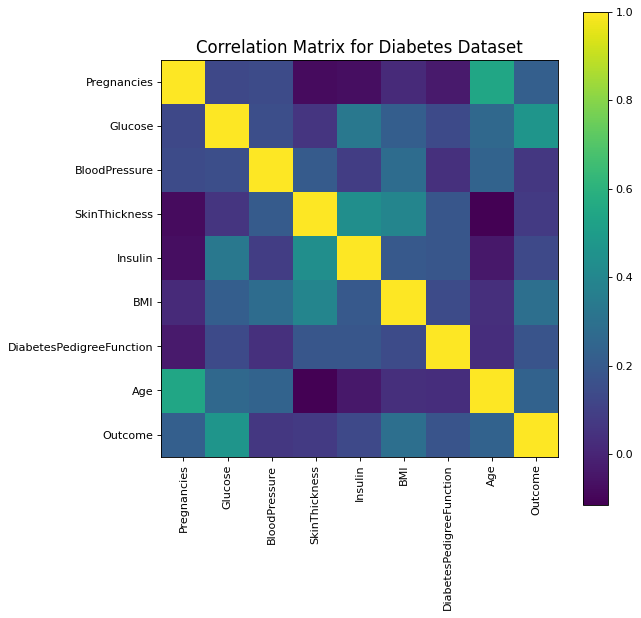

In [19]:
plotCorrelationMatrix(df, 8, 'Diabetes Dataset')

In [26]:
#scatter
def pltScatterMatrix(df, plotSize, textSize):
    df = df.select_dtypes(include=[np.number])
    df.dropna(axis='columns')
    df = df[[col for col in df if df[col].nunique()>1]]
    ColumnNames = list(df)
    if len(ColumnNames)> 10:
      ColumnNames[:10]
    df = df[ColumnNames]
    ax=pd.plotting.scatter_matrix(df, alpha=0.75, figsize=[plotSize, plotSize], diagonal='kde')
    corrs = df.corr().values
    for i, j in zip(*plt.np.triu_indices_from(ax, k=1)):
      ax[i,j].annotate('Corr, coef = %.3f' %corrs[i,j], (0.8, 0.2), xycoords='axes fraction', ha='center',va ='center', size=textSize)
    plt.suptitle('Scatter and Density Plot')
    plt.show()

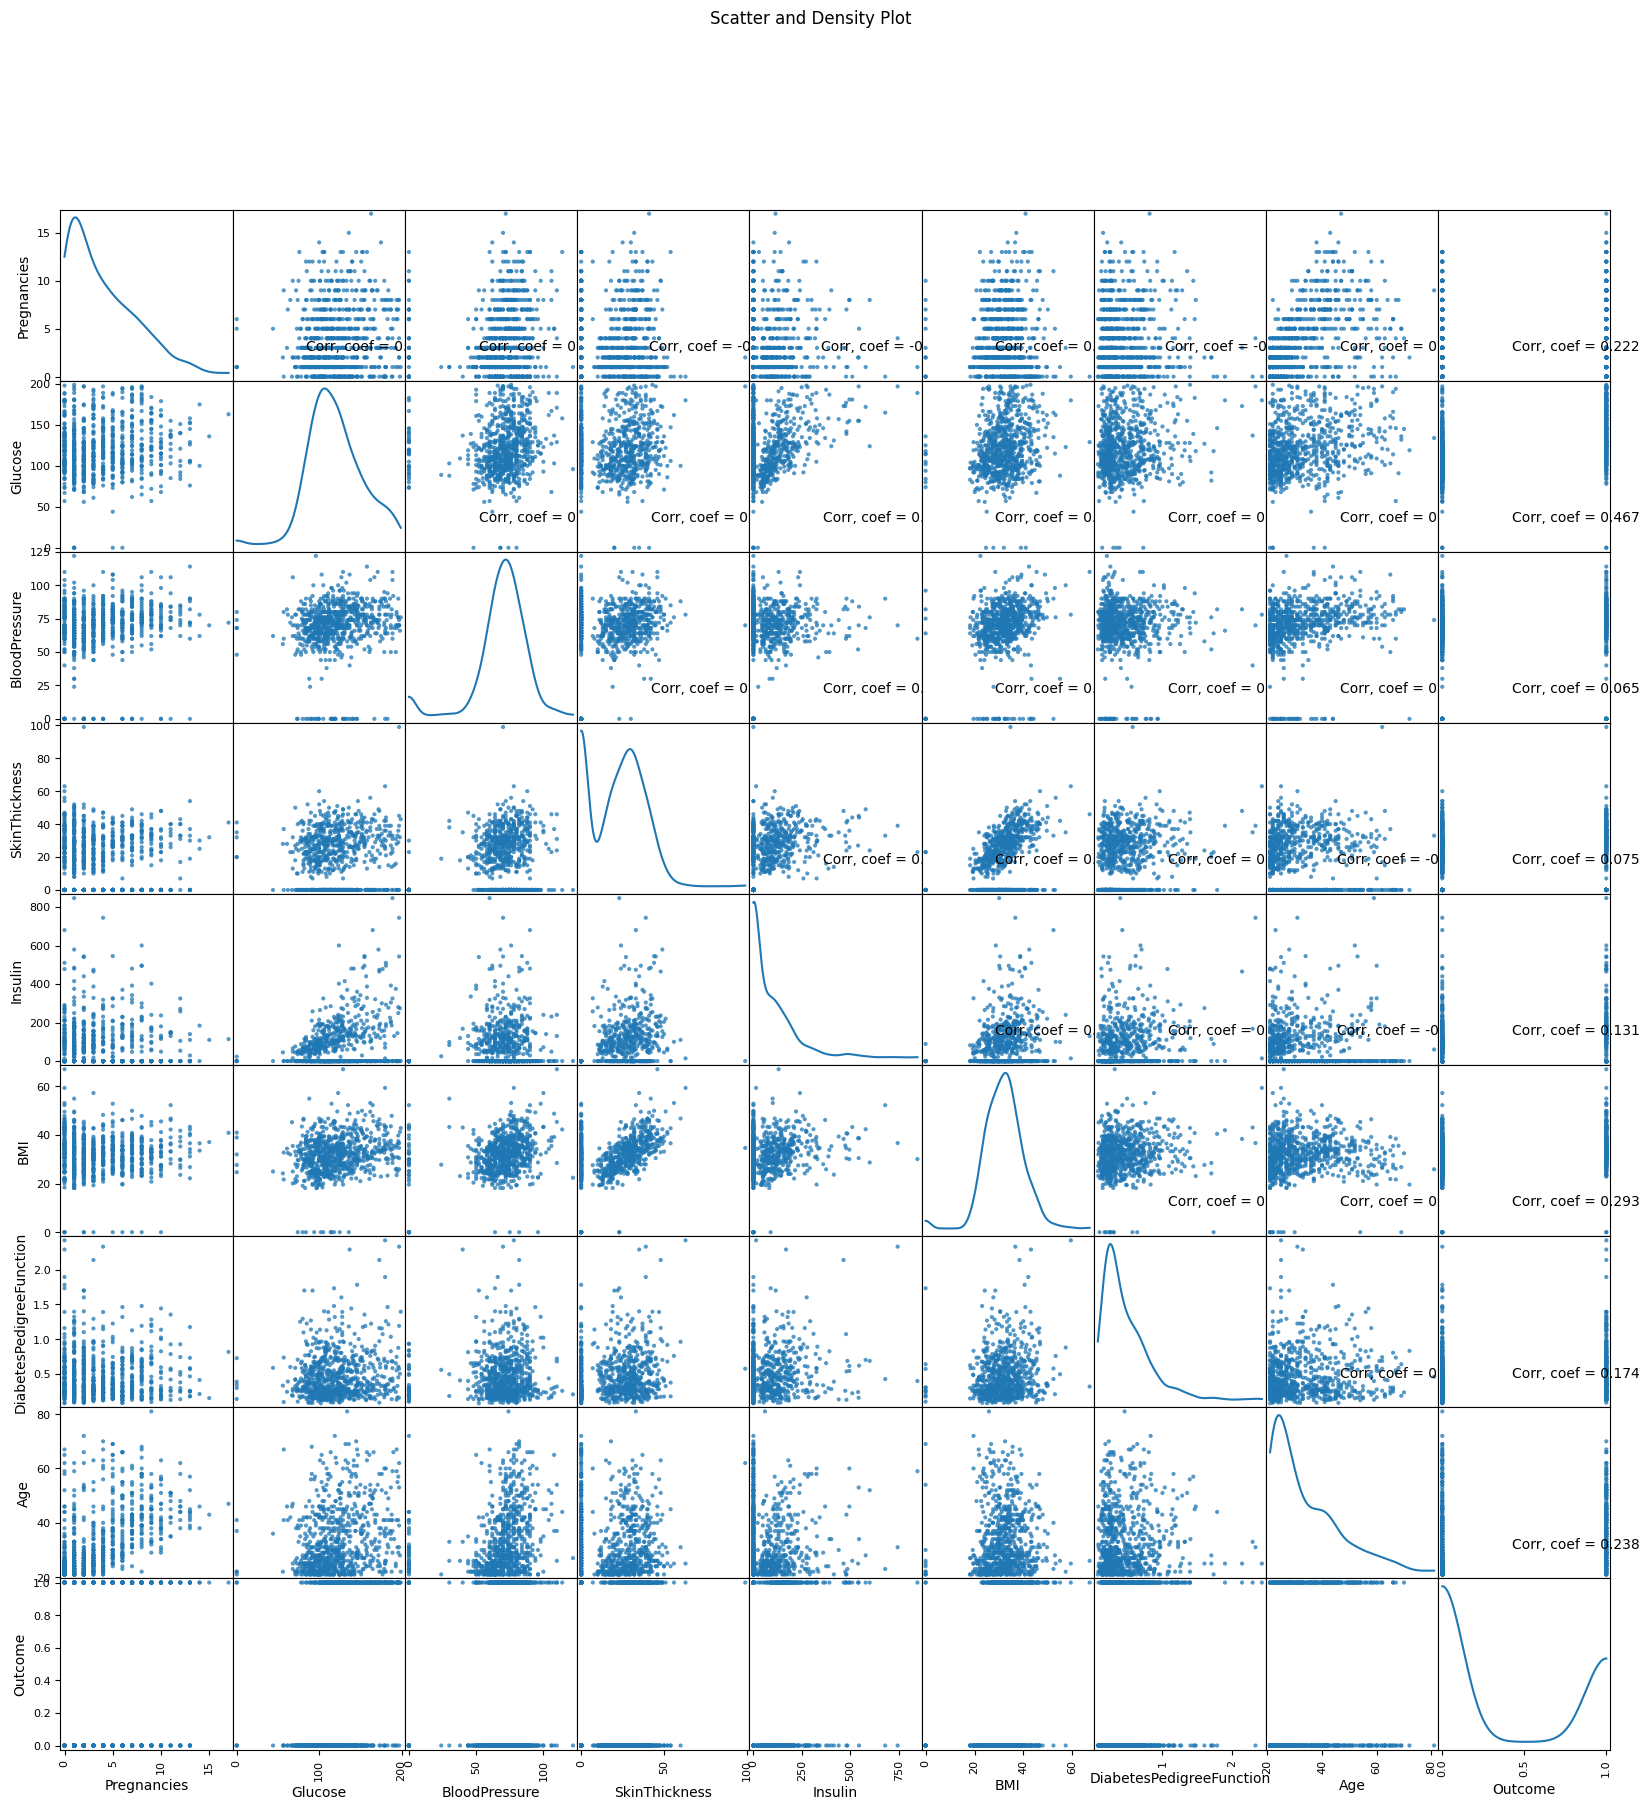

In [27]:
pltScatterMatrix(df, 20, 10)

In [29]:
# split dataset in features and target variable
feature_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
X = df[feature_cols]  # Features
y = df.Outcome  # Target variable

print(X.shape)
print(y.shape)

(768, 7)
(768,)


In [30]:
# Split X and y into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=16)


In [31]:
# instantiate the model (using the default parameters)
logreg = LogisticRegression(random_state=16)

# fit the model with data
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)


In [32]:
y_pred

array([1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1])

In [33]:
cnf_matrix = confusion_matrix(y_test, y_pred)
cnf_matrix

array([[134,  13],
       [ 35,  49]])

Text(0.5, 427.9555555555555, 'Predicted label')

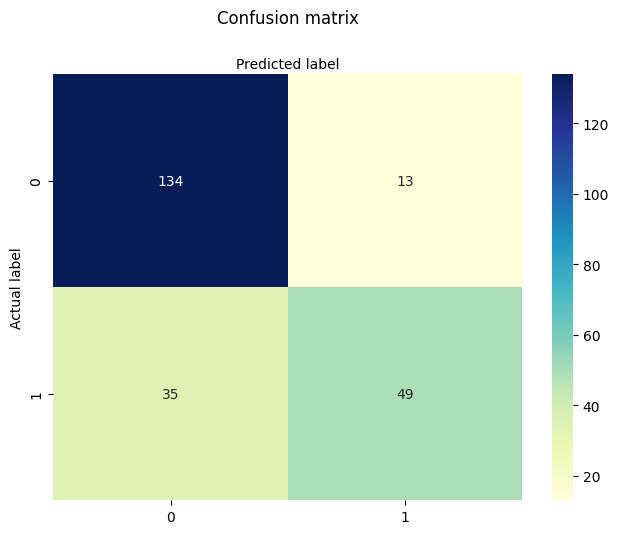

In [34]:
class_names = [0, 1]  # name of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu", fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [35]:
target_names = ['without diabetes', 'with diabetes']
print(classification_report(y_test, y_pred, target_names=target_names))

                  precision    recall  f1-score   support

without diabetes       0.79      0.91      0.85       147
   with diabetes       0.79      0.58      0.67        84

        accuracy                           0.79       231
       macro avg       0.79      0.75      0.76       231
    weighted avg       0.79      0.79      0.78       231



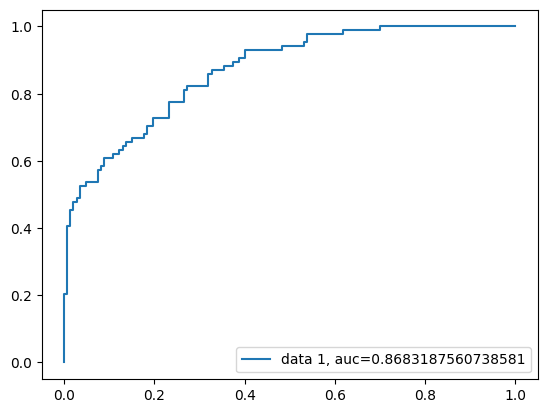

In [36]:
y_pred_proba = logreg.predict_proba(X_test)[::,1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr, tpr, label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()